In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [ ]:
################################################################################

In [ ]:
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep

SBZ_xmaxs=find_SBZ_xmaxs()

In [14]:
#out_arr

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')


ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
list of first 10 ignored parcels
[[18 5 10]
 [218 22 27]
 [246 7 11]
 [357 14 20]
 [414 7 11]]
there are a total of 1290 CL parcels and 1473 nonCL parcels


In [19]:
Ps=ALL_out_arr[:,0]
Ts=ALL_out_arr[:,1]

Coast_x=256
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Coast_Dist=X[t,p]-Coast_x
    Coast_Dist*=kms
    Coast_Lst.append(Coast_Dist)
    
    SBZ_Dist=X[t,p]-SBZ_xmaxs[t]
    SBZ_Dist*=kms
    SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

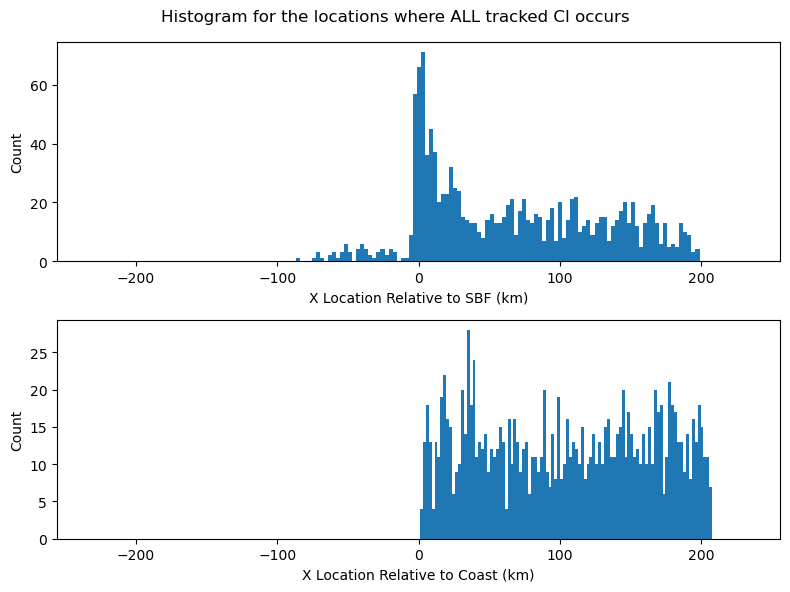

In [20]:
num_bins=100
# num_bins=10

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')
ax1.set_xlim((-256, 256))

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')
ax2.set_xlim((-256, 256))


plt.suptitle('Histogram for the locations where ALL tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap



In [ ]:
####################################################################################

In [15]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
there are a total of 873 CL parcels and 1130 nonCL parcels


In [21]:
Ps=SHALLOW_out_arr[:,0]
Ts=SHALLOW_out_arr[:,1]

Coast_x=256
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Coast_Dist=X[t,p]-Coast_x
    Coast_Dist*=kms
    Coast_Lst.append(Coast_Dist)
    
    SBZ_Dist=X[t,p]-SBZ_xmaxs[t]
    SBZ_Dist*=kms
    SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

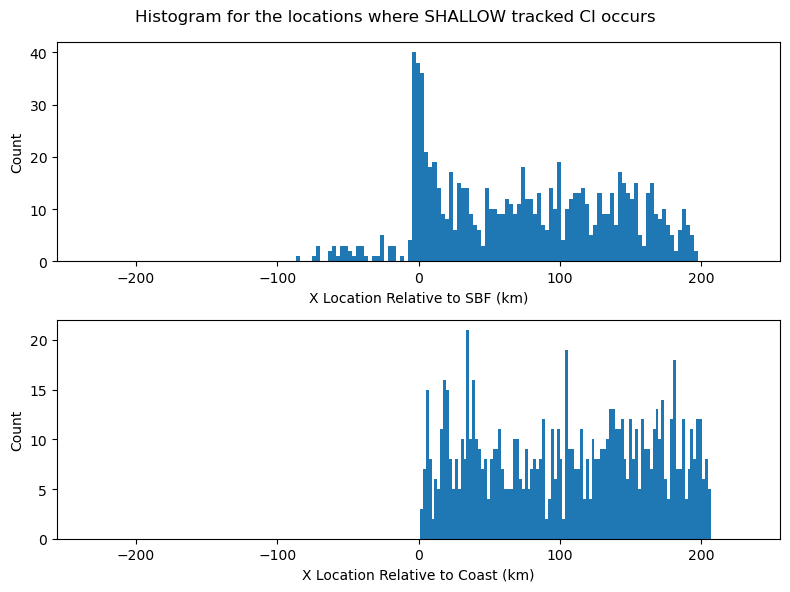

In [23]:
num_bins=100
# num_bins=10

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')
ax1.set_xlim((-256, 256))

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')
ax2.set_xlim((-256, 256))


plt.suptitle('Histogram for the locations where SHALLOW tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap



In [ ]:
#######################################

In [16]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
there are a total of 161 CL parcels and 167 nonCL parcels


In [24]:
Ps=DEEP_out_arr[:,0]
Ts=DEEP_out_arr[:,1]

Coast_x=256
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
for (t,p) in zip(*Position):
    Coast_Dist=X[t,p]-Coast_x
    Coast_Dist*=kms
    Coast_Lst.append(Coast_Dist)
    
    SBZ_Dist=X[t,p]-SBZ_xmaxs[t]
    SBZ_Dist*=kms
    SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

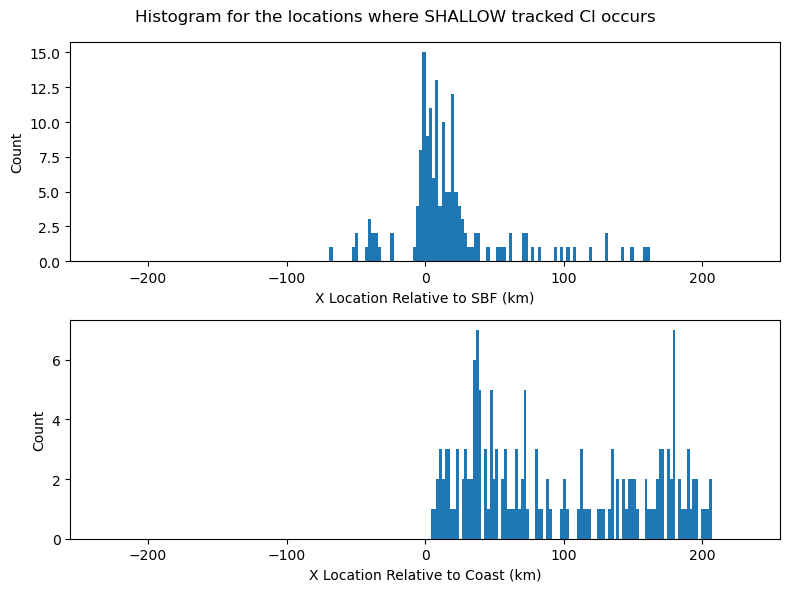

In [25]:
num_bins=100
# num_bins=10

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column

# First subplot: Distance from SBZ Front
ax1 = plt.subplot(gs[0])
ax1.hist(SBZ_Lst, bins=num_bins)
ax1.set_ylabel('Count')
ax1.set_xlabel('X Location Relative to SBF (km)')
ax1.set_xlim((-256, 256))

# Second subplot: Distance from Coast
ax2 = plt.subplot(gs[1])
ax2.hist(Coast_Lst, bins=num_bins)
ax2.set_ylabel('Count')
ax2.set_xlabel('X Location Relative to Coast (km)')
ax2.set_xlim((-256, 256))


plt.suptitle('Histogram for the locations where DEEP tracked CI occurs')
plt.tight_layout()  # Adjust layout to prevent overlap

